# Lección 6 (parte 2) - SARIMA: ARIMA estacional

En esta segunda parte de la lección veremos cómo crear, validar y generar pronósticos con un modelo SARIMA.

## 1. Importación de librerías

In [1]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Modelos ARIMA con stasforecast y statsmodels
from statsforecast import StatsForecast
from statsforecast.models import ARIMA, AutoETS

RUTA = '/Users/miguel/Library/CloudStorage/GoogleDrive-miguel@codificandobits.com/My Drive/02-CODIFICANDOBITS.COM/04-Academia/01-Cursos/45-2026-03-ARIMA/data/'

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 4)

## 2. El set de datos y el problema a resolver

Para este caso usaremos el mismo set de datos de la [lección 8](https://codificandobits.com/curso/pronosticos-series-tiempo-suavizado-exponencial/8-seleccion-modelos-suavizado-exponencial/) del curso "Pronósticos de Series de Tiempo con Suavizado Exponencial".

Es decir que usaremos una serie de tiempo que contiene datos reales de demanda de energía eléctrica en el estado de California.

Los datos contienen un registro histórico de los niveles de demanda energética en California para el periodo comprendido entre el 2025-04-27 17:00 y el 2025-07-20 00:00.

La frecuencia de los datos es horaria y en total se tienen 2000 registros, que equivalente casi a 3 meses.

El problema a resolver será el siguiente:

> Entrenar y validar un modelo SARIMA para generar pronósticos de la demanda de energía eléctrica con un horizonte a 24 horas.

Comencemos cargando el set de datos:

In [2]:
df = pd.read_csv(RUTA + 'demanda_electricidad_california.csv', parse_dates=["ds"])
df

,unique_id,ds,y
0,california,2025-04-27 17:00:00,21997.0
1,california,2025-04-27 18:00:00,21418.0
2,california,2025-04-27 19:00:00,21343.0
3,california,2025-04-27 20:00:00,21908.0
4,california,2025-04-27 21:00:00,22124.0
...,...,...,...
1995,california,2025-07-19 20:00:00,29380.0
1996,california,2025-07-19 21:00:00,27763.0
1997,california,2025-07-19 22:00:00,26659.0
1998,california,2025-07-19 23:00:00,26438.0


Y veamos el comportamiento en el tiempo de la Serie:

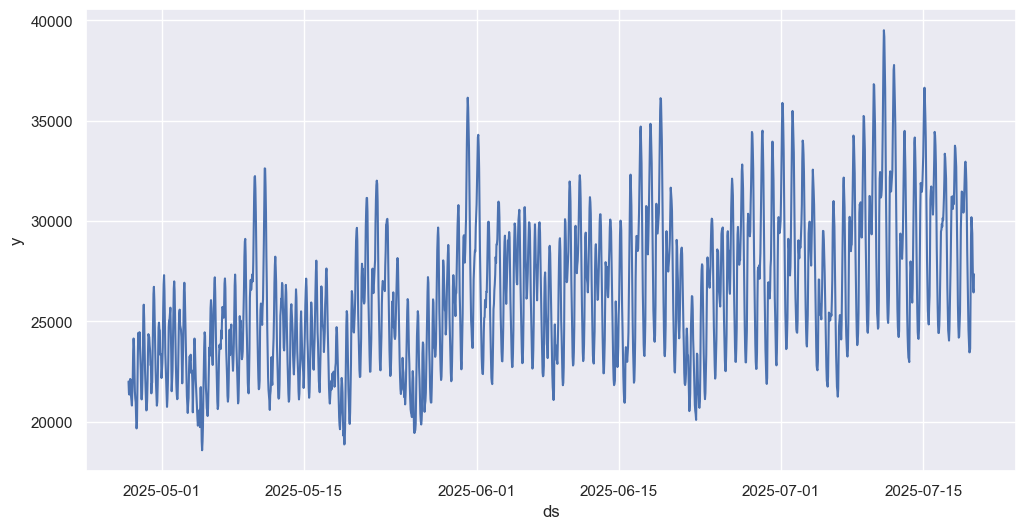

In [3]:
fig, ax = plt.subplots(1,1,figsize=(12,6))
sns.lineplot(df, x="ds", y="y");

En la lección 8 del curso anterior vimos que esta serie es estacional (aunque esto lo comprobaremos en un momento).

## 3. Modelo base

Para hacer un comparativo con la lección 8 del curso anterior, en este caso nuestro modelo base será el mejor modelo encontrado en dicha lección.

Este es un modelo de suavizado exponencial con error multiplicativo, tendencia aditiva amortiguada y estacionalidad multiplicativa.

Así que replicaremos este modelo y evaluaremos su desempeño. Comencemos creando la función "metricas_cv" de la lección anterior:

In [4]:
def metricas_cv(cv_df, nombres_modelos):
    resultados = []
    
    # Iterar por cada modelo (si hay más de uno)    
    for modelo in nombres_modelos:
        # Agrupar por "cutoff" para calcular métricas por ventana
        metricas_ventana = []
        
        for cutoff in cv_df['cutoff'].unique():
            ventana = cv_df[cv_df['cutoff'] == cutoff]
            y_true = ventana['y'] # Observación
            y_pred = ventana[modelo] # Pronóstico
            
            # Calcular y almacenarRMSE y MAPE para la ventana
            rmse = np.sqrt(np.mean((y_true - y_pred)**2))
            mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
            
            metricas_ventana.append({'rmse': rmse, 'mape': mape})
        
        # Convertir resultados anteriores a DataFrame de Pandas
        metricas_df = pd.DataFrame(metricas_ventana)
        
        resultados.append({
            'Modelo': modelo,
            'RMSE_media': metricas_df['rmse'].mean(),
            'RMSE_std': metricas_df['rmse'].std(),
            'MAPE_media(%)': metricas_df['mape'].mean(),
            'MAPE_std(%)': metricas_df['mape'].std()
        })
        
    return pd.DataFrame(resultados)

A continuación creamos los sets de entrenamiento y prueba. El set de prueba serán simplemente las últimas 24 horas de la serie de tiempo:

In [5]:
# Sets de entrenamiento prueba
df_tr = df[:-24]
df_ts = df[-24:]

print(df_tr.tail())
print(df_ts)

       unique_id                  ds        y
1971  california 2025-07-18 20:00:00  31447.0
1972  california 2025-07-18 21:00:00  31102.0
1973  california 2025-07-18 22:00:00  31182.0
1974  california 2025-07-18 23:00:00  30418.0
1975  california 2025-07-19 00:00:00  30741.0
       unique_id                  ds        y
1976  california 2025-07-19 01:00:00  31331.0
1977  california 2025-07-19 02:00:00  32114.0
1978  california 2025-07-19 03:00:00  32908.0
1979  california 2025-07-19 04:00:00  32959.0
1980  california 2025-07-19 05:00:00  32605.0
1981  california 2025-07-19 06:00:00  31926.0
1982  california 2025-07-19 07:00:00  30425.0
1983  california 2025-07-19 08:00:00  28522.0
1984  california 2025-07-19 09:00:00  27161.0
1985  california 2025-07-19 10:00:00  25773.0
1986  california 2025-07-19 11:00:00  24584.0
1987  california 2025-07-19 12:00:00  23949.0
1988  california 2025-07-19 13:00:00  23452.0
1989  california 2025-07-19 14:00:00  23453.0
1990  california 2025-07-19 15:00:

A continuación creamos el modelo base y lo validamos en términos del RMSE y el MAPE (promedio y desviación estándar):

In [6]:
# Instancia del modelo base
modelo_base = [AutoETS(season_length=24, model='MAM', damped=True, alias='modelo_base')]
sf = StatsForecast(
    models=modelo_base,
    freq='h',  # horas
    n_jobs=-1
)

# Validación cruzada: 10 ventanas de tamaño fijo
cv_df = sf.cross_validation(
    df=df_tr,
    h=24, # Horizonte del pronóstico
    step_size=24, # Entre ventanas consecutivas saltar 24 horas
    n_windows=10, # 10 ventanas
)

# Desempeño
metricas_modelo_base = metricas_cv(cv_df, ['modelo_base'])
metricas_modelo_base

,Modelo,RMSE_media,RMSE_std,MAPE_media(%),MAPE_std(%)
0,modelo_base,1635.64075,529.162377,4.504568,1.863908


Estas serán las métricas que usaremos como referencia para nuestro modelo SARIMA.

## 4. El modelo SARIMA

### 4.1. Determinación de los hiper-parámetros (p, d, q, P, D, Q)

Comencemos modificando la función "prueba_diferenciacion" (usada en lecciones anteriores) para que nos permita calcular además diferencias estacionales:

In [7]:
# La misma función usada en la lección anterior
def prueba_diferenciacion(serie, m, d, D, titulo):
    # Eliminar posibles NaN de la serie
    serie = serie.dropna()
    
    # Diferenciar (si d!=0)
    if d != 0:
        for _ in range(d):
            serie = serie.diff()
    
    # Diferencia estacional (si D!=0)
    if D != 0:
        for _ in range(D):
            serie = serie.diff(m)
    
    # Aplicar prueba y mostrar resultado
    resultado = adfuller(serie.dropna())
    pval = resultado[1]
    
    if pval < 0.05:
        # Se rechaza la hipótesis nula: la serie es estacionaria
        print(f'La serie es estacionaria porque p = {pval:.2f} < 0.05. NO se requiere diferenciación')
    else:
        # Se acepta la hipótesis nula: la serie es NO estacionaria
        print(f'La serie NO es estacionaria porque p = {pval:.2f} >= 0.05. Se requiere diferenciación')
        
    # Graficar
    fig, ax = plt.subplots(1,1,figsize=(12,4))
    plt.plot(range(1,len(serie)+1), serie)
    plt.hlines(serie.mean(), xmin=1, xmax=len(serie)+1, color='red', linestyle='--');
    ax.set_title(titulo)

Ahora veamos cómo diferentes órdenes de diferenciación *(d,D)* afectan la estacionariedad de la serie obtenida. En adelante usaremos sólo el set de entrenamiento:

La serie NO es estacionaria porque p = 0.19 >= 0.05. Se requiere diferenciación


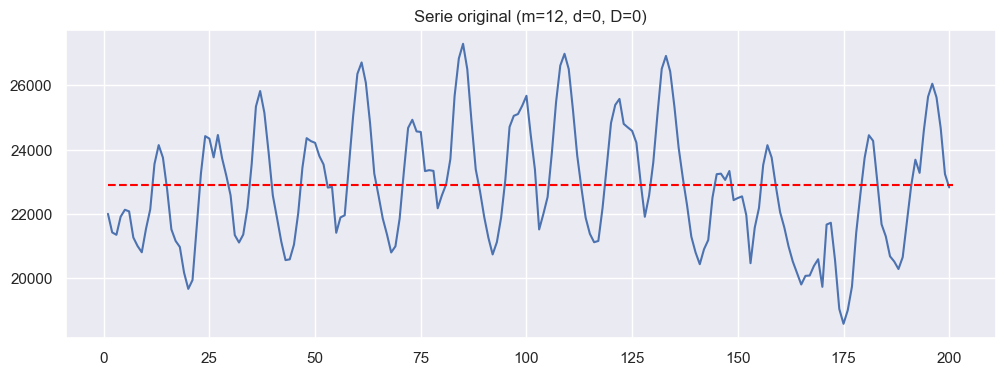

In [8]:
# Serie original (aplicarlo sobre una parte de la serie para que la prueba de estacionariedad funcione)
prueba_diferenciacion(df_tr['y'][:200], m=24, d=0, D=0, titulo='Serie original (m=12, d=0, D=0)')

La serie NO es estacionaria porque p = 0.38 >= 0.05. Se requiere diferenciación


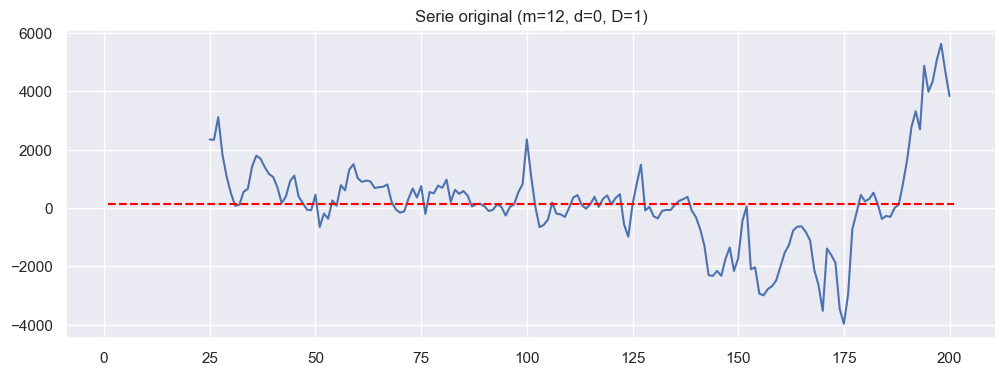

In [9]:
# Serie d=0, D=1 (aplicarlo sobre una parte de la serie para que la prueba de estacionariedad funcione)
prueba_diferenciacion(df_tr['y'][:200], m=24, d=0, D=1, titulo='Serie original (m=12, d=0, D=1)')

La serie es estacionaria porque p = 0.00 < 0.05. NO se requiere diferenciación


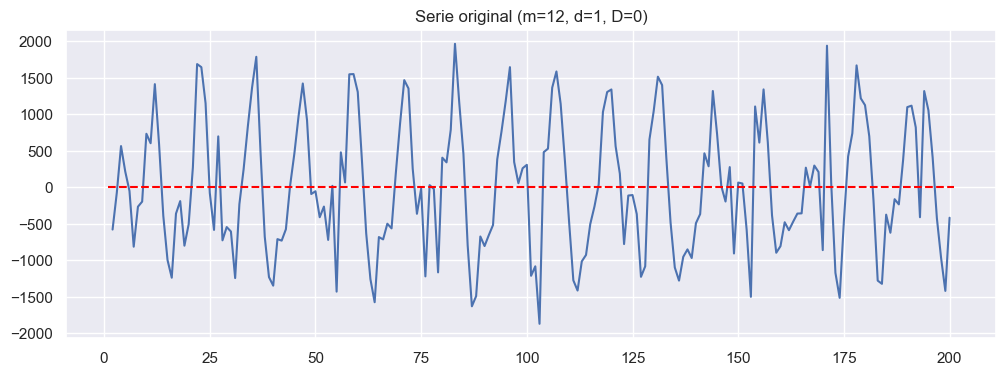

In [10]:
# Serie d=1, D=0 (aplicarlo sobre una parte de la serie para que la prueba de estacionariedad funcione)
prueba_diferenciacion(df_tr['y'][:200], m=24, d=1, D=0, titulo='Serie original (m=12, d=1, D=0)')

La serie es estacionaria porque p = 0.00 < 0.05. NO se requiere diferenciación


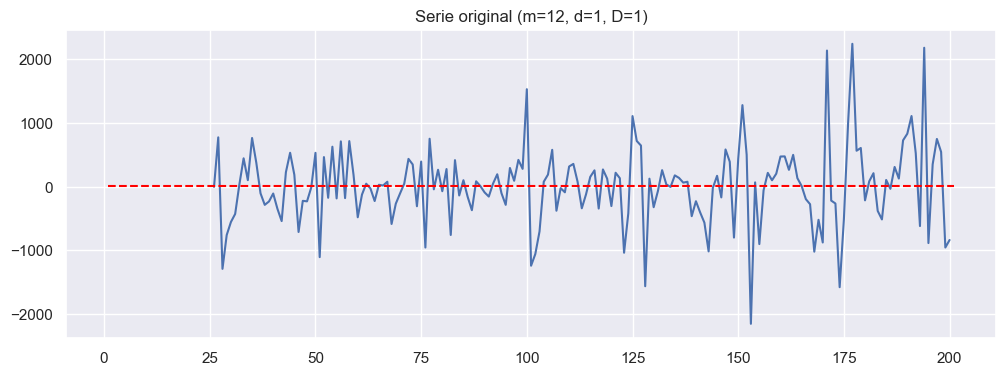

In [11]:
# Serie d=1, D=1 (aplicarlo sobre una parte de la serie para que la prueba de estacionariedad funcione)
prueba_diferenciacion(df_tr['y'][:200], m=24, d=1, D=1, titulo='Serie original (m=12, d=1, D=1)')

Y de lo anterior podemos concluir que:

- *d=1*
- *D = {1}*

Veamos ahora cómo elegir p, q, P y Q.

Comencemos dibujando la ACF y la PACF para la primera combinación de órdenes de diferenciación (d=1, D=0):

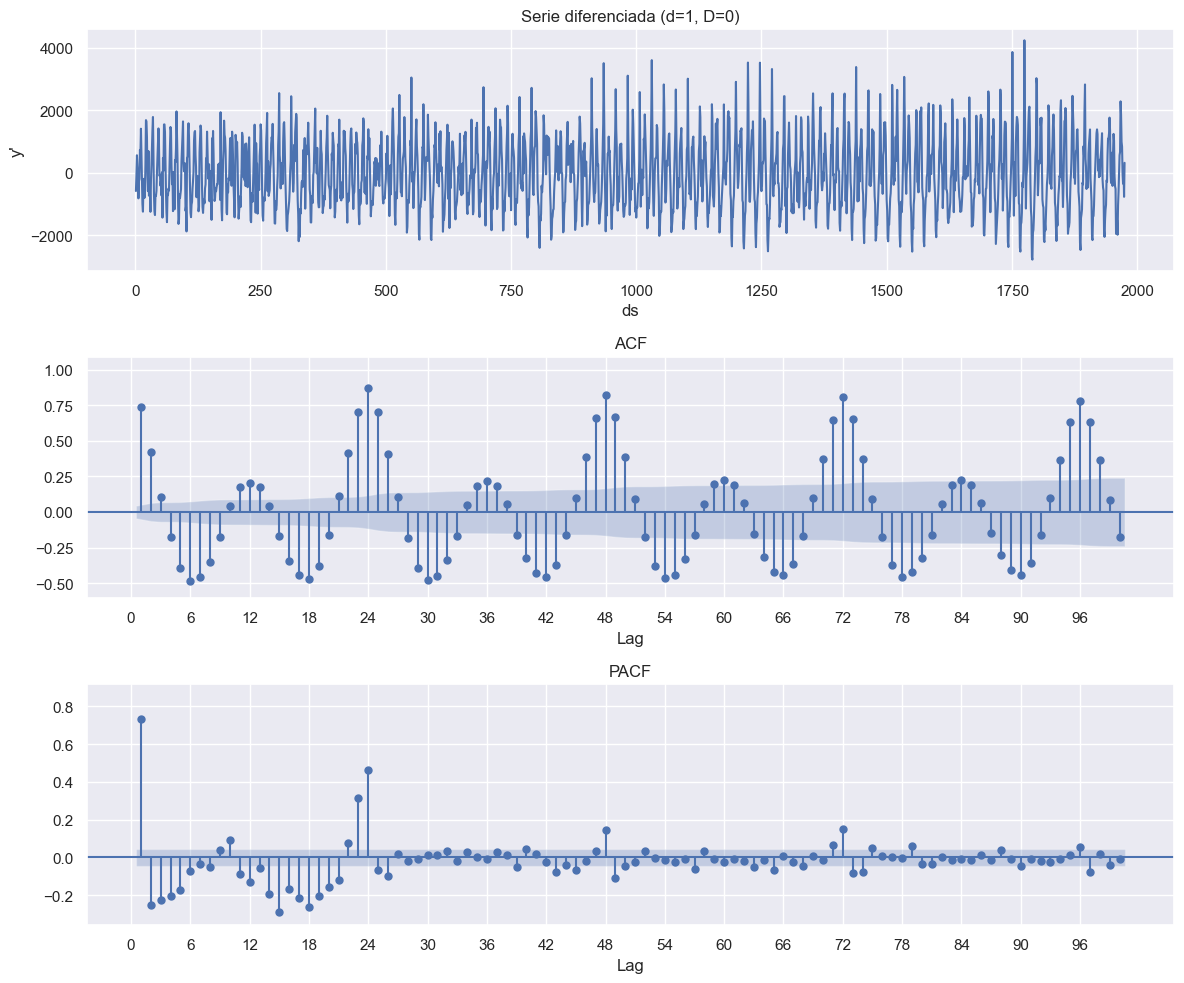

In [12]:
# ACF y PACF con d=1, D=0

# Calcular primera diferencia de la Serie (d=1, D=0)
df_dif1 = df_tr['y'].diff().dropna()

# Dibujar serie diferenciada, función de autocorrelación y PACF
fig, axs = plt.subplots(3,1,figsize=(12,10))

sns.lineplot(df_dif1[:], ax=axs[0])
axs[0].set_xlabel('ds')
axs[0].set_ylabel("y'")
axs[0].set_title('Serie diferenciada (d=1, D=0)')

LAGS = 100
plot_acf(df_dif1,
         alpha=0.05, # Intervalo de confianza del 95%
         lags=LAGS,
         zero=False,
         auto_ylims=True,
         ax=axs[1])
axs[1].set_xlabel('Lag')
axs[1].set_xticks(range(0,LAGS+1))
axs[1].set_title('ACF')
axs[1].set_xticks(range(0, LAGS + 1, 6))
axs[1].grid(True)

plot_pacf(df_dif1,
          lags=LAGS,
          zero=False,
          auto_ylims=True,
          ax=axs[2])
axs[2].set_xlabel('Lag')
axs[2].set_xticks(range(0,LAGS+1))
axs[2].set_title('PACF')
axs[2].set_xticks(range(0, LAGS + 1, 6))
axs[2].grid(True)

plt.tight_layout()


Vemos que la estacionalidad de la serie es de 24 horas. Sin embargo, !es necesario usar un D diferente de 0! pues al no hacerlo se preserva el componente estacional y por un lado la Serie es no estacionaria pero por otro resulta difícil interpretar lo que ocurre en la ACF.

Veamos qué ocurre con d=1 y D=1 (recordando que m = 24):

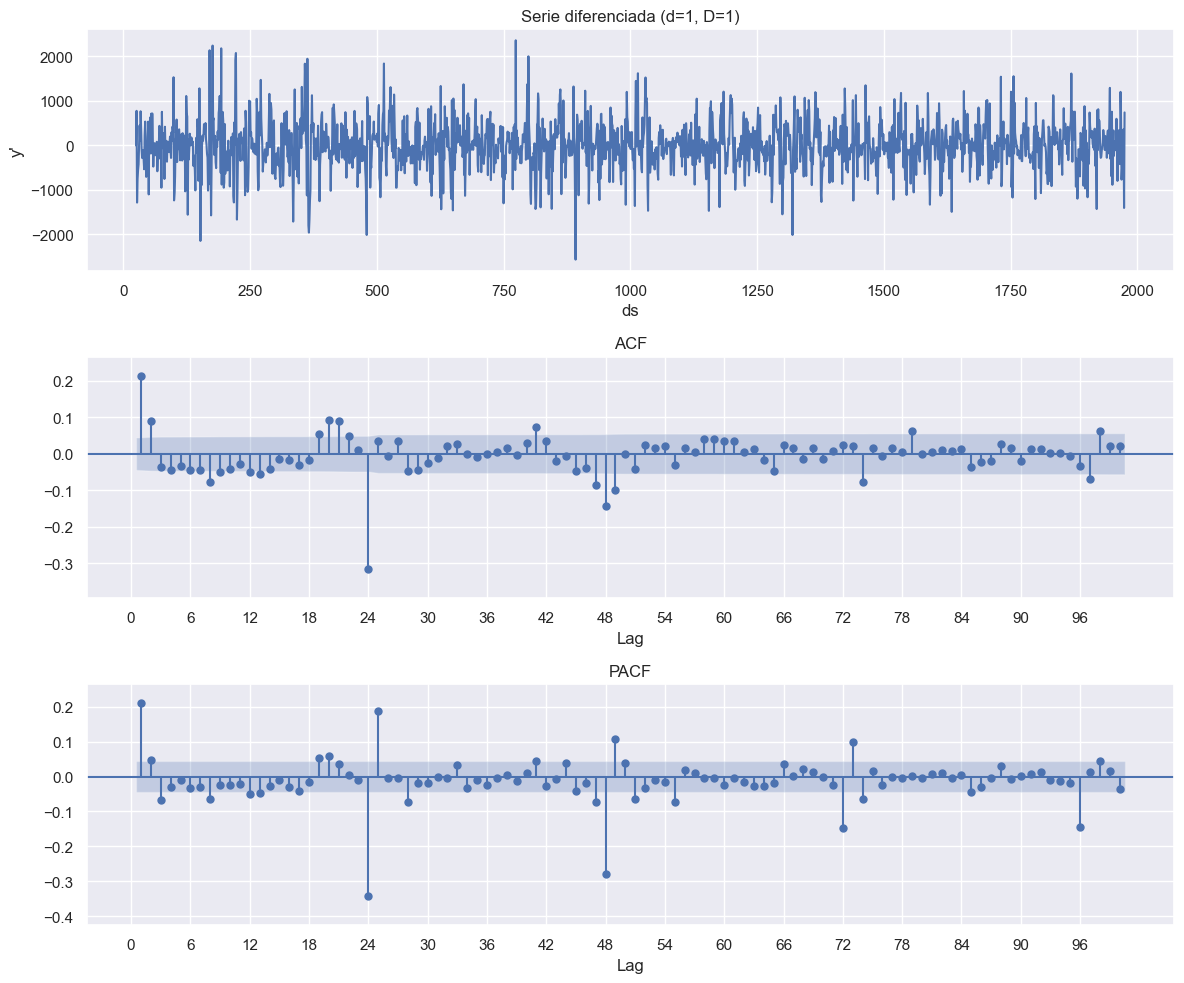

In [13]:
# ACF y PACF con d=1, D=1

# Calcular primera diferencia de la Serie (d=1, D=1)
df_dif1 = df_tr['y'].diff().dropna()
df_dif1 = df_dif1.diff(24).dropna()

# Dibujar serie diferenciada, función de autocorrelación y PACF
fig, axs = plt.subplots(3,1,figsize=(12,10))

sns.lineplot(df_dif1[:], ax=axs[0])
axs[0].set_xlabel('ds')
axs[0].set_ylabel("y'")
axs[0].set_title('Serie diferenciada (d=1, D=1)')

LAGS = 100
plot_acf(df_dif1,
         alpha=0.05, # Intervalo de confianza del 95%
         lags=LAGS,
         zero=False,
         auto_ylims=True,
         ax=axs[1])
axs[1].set_xlabel('Lag')
axs[1].set_xticks(range(0,LAGS+1))
axs[1].set_title('ACF')
axs[1].set_xticks(range(0, LAGS + 1, 6))
axs[1].grid(True)

plot_pacf(df_dif1,
          alpha=0.05, # Intervalo de confianza del 95%
          lags=LAGS,
          zero=False,
          auto_ylims=True,
          ax=axs[2])
axs[2].set_xlabel('Lag')
axs[2].set_xticks(range(0,LAGS+1))
axs[2].set_title('PACF')
axs[2].set_xticks(range(0, LAGS + 1, 6))
axs[2].grid(True)

plt.tight_layout()


Y con esta diferenciación estacional D=1 ya resulta mucho más fácil analizar el comportamiento de la ACF y también de la PACF.

Observaciones:

- Los lags 1 y 2 son los más relevantes en la ACF. Entonces asumiremos $q = {1,2}$
- En la ACF observamos que los lags en 24 y 48 son relevantes. Entonces asumiremos $Q = {1,2}$
- En la PACF sólo el lag 1 es el más relevante. Entonces asumiremos $p = 1$
- Y acá una observación interesante: para múltiplos enteros de 24 **la PACF no decrece abruptamente**. Así que en este caso P = 0

Y con esto ya tenemos nuestra grilla de hiper-parámetros. Ahora la idea es escoger el mejor modelo a partir de esta grilla.

### 4.2. Selección del mejor modelo SARIMA

Acá usaremos la misma idea vista en la lección anterior: por cada combinación de hiper-parámetros entrenaremos y validaremos un modelo y escogeremos al final el modelo con el mejor desempeño.

Así que la implementación será muy similar a la que vimos en la lección anterior:

In [14]:
# Grilla de hiper-parámetros
d = 1
D = 1
qs = [1,2]
Qs = [1,2]
p = 1
P = 0

# Crear lista de modelos StatsForecast
modelos = [
    ARIMA(
        order=(p, d, q), # Para ARIMA
        seasonal_order=(P,D,Q), # Para la parte estacional
        season_length=24, # Estacionalidad de la serie
        alias=f'ARIMA({p},{d},{q})({P},{D},{Q})_24',
        include_constant=False # no incluiremos la constante
    ) 
    for q in qs
    for Q in Qs
]

# Crear instancias
# n_jobs=-1 para usar todas las CPUs al entrenar los modelos en paralelo
sf = StatsForecast(
    models=modelos,
    freq='h',  # horas
    n_jobs=-1
)

print(f"Se crearon {len(modelos)} modelos.")
modelos

Se crearon 4 modelos.


[ARIMA(1,1,1)(0,1,1)_24,
 ARIMA(1,1,1)(0,1,2)_24,
 ARIMA(1,1,2)(0,1,1)_24,
 ARIMA(1,1,2)(0,1,2)_24]

Y ahora hacemos la validación cruzada de cada modelo y evaluamos su desempeño. En la función "cross_validation" usaremos los mismos parámetros definidos para el modelo base:

In [15]:
# Validación cruzada
cv_df = sf.cross_validation(
    df=df_tr,
    h=24, 
    step_size=24, 
    n_windows=10,
)

# Cálculo de desempeños
alias_modelos = [m.alias for m in modelos]
metricas_modelos = metricas_cv(cv_df, alias_modelos)
metricas_modelos

,Modelo,RMSE_media,RMSE_std,MAPE_media(%),MAPE_std(%)
0,"ARIMA(1,1,1)(0,1,1)_24",1672.325642,1173.839965,5.033554,3.713008
1,"ARIMA(1,1,1)(0,1,2)_24",1619.220264,1079.446562,4.817195,3.426555
2,"ARIMA(1,1,2)(0,1,1)_24",1649.634455,1160.099373,4.957289,3.661864
3,"ARIMA(1,1,2)(0,1,2)_24",1597.647373,1077.517831,4.748453,3.411308


En este punto es evidente que el mejor modelo es ARIMA(1,1,2)(0,1,2)_24 con:

- RMSE = 1597.65 +- 1077.51
- MAPE = 4.75 +- 3.41 %

Comparemos esto con el modelo base (lección 8 del curso anterior):

In [16]:
metricas_modelo_base

,Modelo,RMSE_media,RMSE_std,MAPE_media(%),MAPE_std(%)
0,modelo_base,1635.64075,529.162377,4.504568,1.863908


Realmente tienen un desempeño muy similar, siendo el modelo base ligeramente mejor.

## 5. Generación de pronósticos con el modelo SARIMA seleccionado

Nos resta únicamente ver cómo son los pronósticos generados por el modelo. Así que para el modelo seleccionado:

- Calcularemos los pronósticos a 24 horas
- Dibujaremos los valores reales (set de prueba), los pronósticos y el intervalo de predicción

Y compararemos esto con lo arrojado por el modelo base:

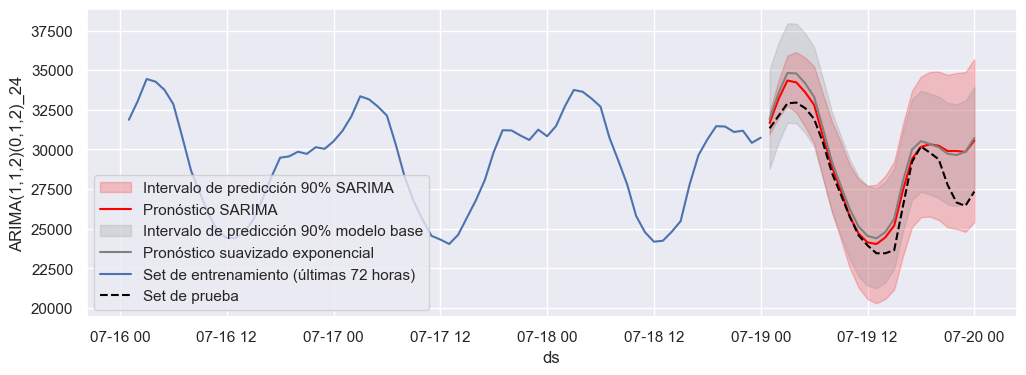

In [17]:
# Crear instancia de los modelos SARIMA y base y entrenar con el set de entrenamiento
sf = StatsForecast(models = [ARIMA(order=(1,1,2), seasonal_order=(0,1,2), season_length=24, alias='ARIMA(1,1,2)(0,1,2)_24'),
                            AutoETS(season_length=24, model='MAM', damped=True, alias='modelo_base')],
                   freq='h')
sf.fit(df_tr)

# Pronósticos a 24 horas
fc = sf.forecast(df=df_tr, h=24, level=[90])

# Graficar
fig, ax = plt.subplots()

# SARIMA: pronóstico puntual e intervalo de predicción
plt.fill_between(x=fc["ds"],
                 y1 = fc['ARIMA(1,1,2)(0,1,2)_24-lo-90'],
                 y2 = fc['ARIMA(1,1,2)(0,1,2)_24-hi-90'],
                 color = 'red',
                 alpha = 0.2,
                 label = 'Intervalo de predicción 90% SARIMA');
sns.lineplot(fc, x="ds", y="ARIMA(1,1,2)(0,1,2)_24", color='red', label='Pronóstico SARIMA');

# Modelo base suavizado exponencial: pronóstico puntual e intervalo de predicción
plt.fill_between(x=fc["ds"],
                 y1 = fc['modelo_base-lo-90'],
                 y2 = fc['modelo_base-hi-90'],
                 color = 'gray',
                 alpha = 0.2,
                 label = 'Intervalo de predicción 90% modelo base');
sns.lineplot(fc, x="ds", y="modelo_base", color='gray', label='Pronóstico suavizado exponencial');

# Set de entrenamiento (últimas 72 horas) y set de prueba
sns.lineplot(df_tr[-24*3:], x="ds", y="y", label='Set de entrenamiento (últimas 72 horas)');
sns.lineplot(df_ts, x="ds", y="y", label='Set de prueba', color='black', linestyle='--');

Observaciones:

- Los dos pronósticos puntuales son realmente muy similares, lo cual coincide con las métricas de desempeño de ambos modelos
- Y ambos están muy cerca del valor real (set de prueba), aunque durante las últimas 8 horas los pronósticos se alejan bastante del valor real
- El intervalo de predicción del modelo base es más amplio en la primera mitad comparado con el del modelo SARIMA (hay más incertidumbre en el primero que en el segundo).
- Pero los roles se intercambian en la última mitad (hay más incertidumbre en SARIMA que en el modelo base)